# 🌦️ Weather Data Analysis

## Project Overview

This project analyzes historical weather data using Python, Pandas, NumPy, Matplotlib, and Seaborn.

The analysis focuses on temperature, precipitation, wind speed, and weather conditions to identify useful patterns and trends.

## Objectives

- Load and understand a real weather dataset
- Clean basic missing data
- Perform exploratory data analysis
- Analyze temperature and rainfall patterns
- Visualize weather conditions
- Extract meaningful insights from the dataset

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

===== WEATHER DATA ANALYSIS =====

First 5 rows:
  location        date  precipitation  temp_max  temp_min  wind  weather
0  Seattle  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  Seattle  2012-01-02           10.9      10.6       2.8   4.5     rain
2  Seattle  2012-01-03            0.8      11.7       7.2   2.3     rain
3  Seattle  2012-01-04           20.3      12.2       5.6   4.7     rain
4  Seattle  2012-01-05            1.3       8.9       2.8   6.1     rain

Dataset Shape:
(2922, 7)

Column Names:
['location', 'date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather']

Missing Values Before Cleaning:
location         0
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

Missing Values After Cleaning:
location         0
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

===== SUMMARY STATISTICS =====
  

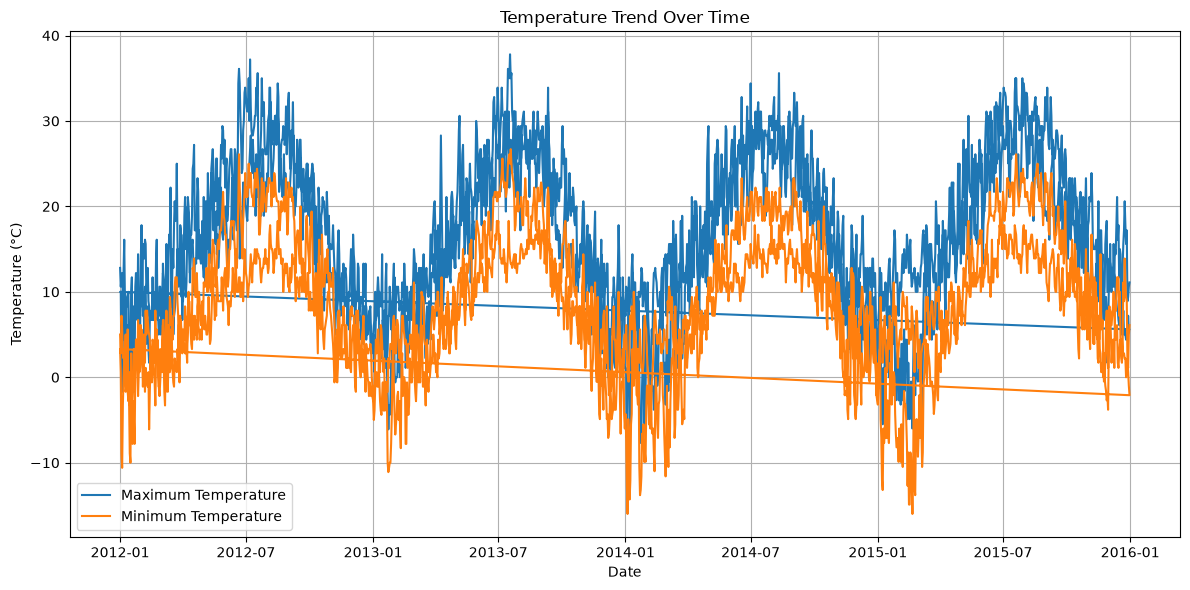

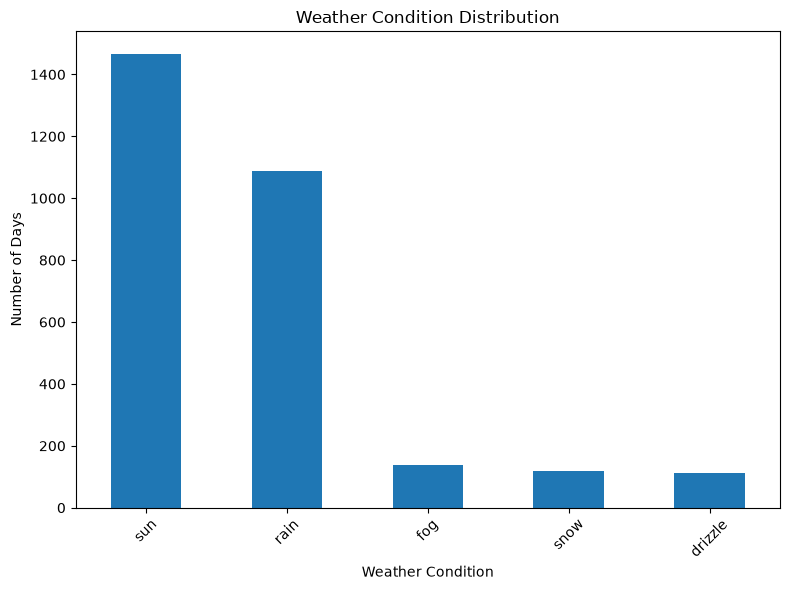

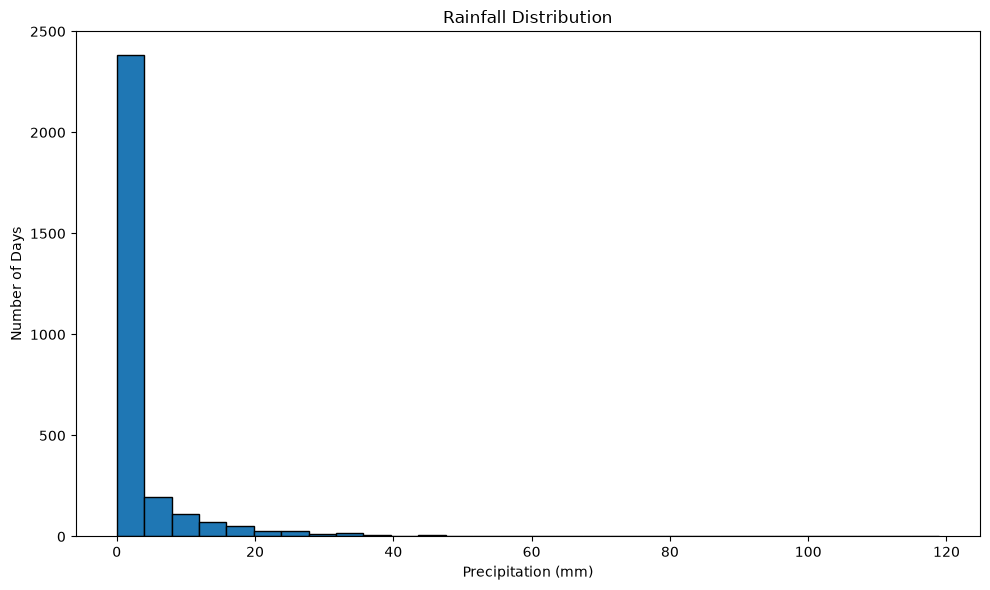

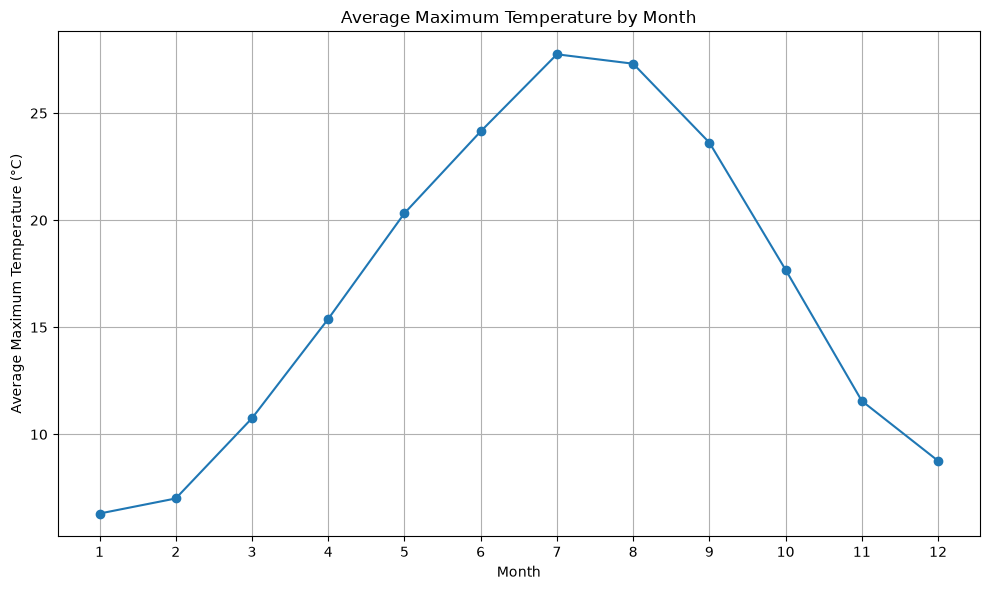


===== PROJECT COMPLETED =====
Dataset cleaned successfully.
Four visualizations created successfully.
Insight summary generated successfully.
Chart images saved inside the outputs folder.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("outputs", exist_ok=True)

df = pd.read_csv("weather.csv")

print("===== WEATHER DATA ANALYSIS =====")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

df["date"] = pd.to_datetime(df["date"])

numeric_columns = ["precipitation", "temp_max", "temp_min", "wind"]

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

df["weather"] = df["weather"].fillna(df["weather"].mode()[0])

df = df.dropna(subset=["date"])

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df["month_name"] = df["date"].dt.month_name()

print("\n===== SUMMARY STATISTICS =====")
print(df[["precipitation", "temp_max", "temp_min", "wind"]].describe())

weather_counts = df["weather"].value_counts()

monthly_temperature = df.groupby("month")["temp_max"].mean()

monthly_rainfall = df.groupby("month")["precipitation"].sum()

print("\nWeather Conditions:")
print(weather_counts)

print("\nAverage Maximum Temperature by Month:")
print(monthly_temperature.round(2))

print("\nTotal Rainfall by Month:")
print(monthly_rainfall.round(2))

highest_temp_row = df.loc[df["temp_max"].idxmax()]
lowest_temp_row = df.loc[df["temp_min"].idxmin()]
highest_rain_row = df.loc[df["precipitation"].idxmax()]

print("\n===== KEY INSIGHTS =====")

print("1. The highest recorded maximum temperature was",
      round(highest_temp_row["temp_max"], 2), "°C on",
      highest_temp_row["date"].date())

print("2. The lowest recorded minimum temperature was",
      round(lowest_temp_row["temp_min"], 2), "°C on",
      lowest_temp_row["date"].date())

print("3. The highest single-day precipitation was",
      round(highest_rain_row["precipitation"], 2), "mm on",
      highest_rain_row["date"].date())

print("4. The most common weather condition was",
      weather_counts.idxmax(), "with",
      weather_counts.max(), "days.")

print("5. The warmest month based on average maximum temperature was",
      monthly_temperature.idxmax(), "with an average of",
      round(monthly_temperature.max(), 2), "°C.")

print("6. The month with the highest total precipitation was",
      monthly_rainfall.idxmax(), "with",
      round(monthly_rainfall.max(), 2), "mm.")

print("7. The average maximum temperature across the dataset was",
      round(df["temp_max"].mean(), 2), "°C.")

print("8. The average wind speed across the dataset was",
      round(df["wind"].mean(), 2), "km/h.")

plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["temp_max"], label="Maximum Temperature")
plt.plot(df["date"], df["temp_min"], label="Minimum Temperature")
plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("outputs/temperature_trend.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
weather_counts.plot(kind="bar")
plt.title("Weather Condition Distribution")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/weather_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df["precipitation"], bins=30, edgecolor="black")
plt.title("Rainfall Distribution")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.savefig("outputs/rainfall_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(monthly_temperature.index, monthly_temperature.values, marker="o")
plt.title("Average Maximum Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Maximum Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid()
plt.tight_layout()
plt.savefig("outputs/monthly_temperature.png", dpi=300)
plt.show()

print("\n===== PROJECT COMPLETED =====")
print("Dataset cleaned successfully.")
print("Four visualizations created successfully.")
print("Insight summary generated successfully.")
print("Chart images saved inside the outputs folder.")

## 📚 Dataset Source

Dataset: Weather Dataset

Source:
https://github.com/observablehq/sample-datasets/blob/main/weather.csv

The dataset contains daily weather observations including location, date, precipitation, maximum temperature, minimum temperature, wind speed, and weather condition.